In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = "/content/drive/MyDrive/tarea 3/df_1.xlsx"
df = pd.read_excel(path)

print(df.shape)
df.head()


(19908, 17)


,loan_amnt,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,addr_state,dti,delinq_2yrs,revol_util,pub_rec_bankruptcies
0,7.7832,36,15.9600,84.3300,C,Missing,10+ years,RENT,9.4134,Not Verified,Fully Paid,small_business,IL,8.7200,0,98.5000,0
1,9.2103,36,13.4900,339.3100,C,AIR RESOURCES BOARD,10+ years,RENT,10.8036,Source Verified,Fully Paid,other,CA,20.0000,0,21.0000,0
2,8.0064,36,18.6400,109.4300,E,MKC Accounting,9 years,RENT,10.7790,Source Verified,Fully Paid,car,CA,5.3500,0,87.5000,0
3,8.6305,60,21.2800,152.3900,F,Missing,4 years,OWN,10.5966,Source Verified,Charged Off,small_business,CA,5.5500,0,32.6000,0
4,8.5895,60,12.6900,121.4500,B,Starbucks,< 1 year,RENT,9.6158,Verified,Charged Off,other,TX,18.0800,0,36.5000,0


In [4]:
df['addr_state'].value_counts()


,count
addr_state,
CA,7101
NY,3813
FL,2870
TX,2733
NJ,1855
IL,1525
Missing,9
951xx,1
106xx,1


Este código primero elimina todas las filas donde la variable objetivo loan_status está vacía (Missing) porque para entrenar un modelo de clasificación supervisada necesitamos que cada fila tenga una etiqueta. Luego, convertimos los valores categóricos "Fully Paid" y "Charged Off" en números binarios (0 y 1) usando map(), lo que permite que los modelos de Machine Learning interpreten la variable objetivo correctamente. Esto asegura que no haya datos faltantes en la columna clave y que la variable esté en un formato numérico que los algoritmos puedan manejar.

In [5]:
df['loan_status'] = (
    df['loan_status']
    .str.strip()
    .str.lower()
    .map({'fully paid': 0, 'charged off': 1})
)

df = df[df['loan_status'].notna()]
df['loan_status'] = df['loan_status'].astype(int)



Primero agrupamos la columna emp_length en rangos lógicos para reducir la cardinalidad y evitar categorías con pocas observaciones, reemplazando los valores "Missing" por "Unknown". Esto permite que el OrdinalEncoder funcione sin errores, ya que requiere que todos los valores estén dentro de la lista de categorías definidas. Para grade no es necesario agrupar porque tiene pocas categorías y un orden natural claro, lo que permite que el modelo aproveche la jerarquía de mejor a peor (A a G). Luego definimos explícitamente el orden de las categorías para cada columna: grade_order para grade y emp_length_order para emp_length. Creamos un OrdinalEncoder de Scikit-Learn pasando estas categorías ordenadas y establecemos dtype=int para que los valores resultantes sean enteros. Aplicamos el codificador directamente sobre las columnas originales grade y emp_length usando fit_transform y convertimos el resultado a enteros con .astype(int) para que pandas no mantenga el tipo object. El resultado es que ambas columnas quedan codificadas numéricamente respetando su jerarquía: grade de 0 a 6 y emp_length de 0 a 5 (incluyendo Unknown). Esto asegura que las columnas estén listas para modelos de Machine Learning, sin pérdida de información ordinal ni problemas de cardinalidad.

In [6]:
from sklearn.preprocessing import OrdinalEncoder

# --- Agrupar emp_length ---
def group_emp_length(emp):
    if emp in ['< 1 year', '1 year', '2 years']:
        return '0-2 years'
    elif emp in ['3 years', '4 years']:
        return '3-4 years'
    elif emp in ['5 years', '6 years']:
        return '5-6 years'
    elif emp in ['7 years', '8 years', '9 years']:
        return '7-9 years'
    elif emp == '10+ years':
        return '10+ years'
    else:
        return 'Unknown'

# Aplicar agrupamiento directamente sobre emp_length
df['emp_length'] = df['emp_length'].replace('Missing', 'Unknown').apply(group_emp_length)

# --- Definir orden de categorías ---
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
emp_length_order = ['0-2 years', '3-4 years', '5-6 years', '7-9 years', '10+ years', 'Unknown']

# Columnas ordinales
ordinal_cols = ['grade', 'emp_length']

# Crear el codificador
ordinal_encoder = OrdinalEncoder(categories=[grade_order, emp_length_order], dtype=int)

# Aplicar codificación sobre las columnas originales
df[ordinal_cols] = ordinal_encoder.fit_transform(df[ordinal_cols]).astype(int)


Por qué se creó df_1

Se creó un df_1 para transformar y analizar la variable emp_title en toda la muestra, agrupando categorías de baja frecuencia en “Other” y manteniendo “Missing” como categoría separada.
El objetivo fue evaluar su distribución real y verificar si la variable tenía variabilidad suficiente para ser utilizada.

El resultado mostró que más del 93% de las observaciones se concentraban en “Other”, por lo que emp_title presentaba muy baja información útil.

In [7]:
import pandas as pd

MIN_COUNT = 50

df_1 = df

# 1. Estandarizar missing
df_1["emp_title"] = df_1["emp_title"].fillna("Missing")

# 2. Contar frecuencias
counts = df_1["emp_title"].value_counts()

# 3. Categorías frecuentes
keep = counts[counts >= MIN_COUNT].index

# 4. Agrupar raras
df_1["emp_title"] = df_1["emp_title"].where(
    df_1["emp_title"].isin(keep),
    "Other"
)


In [8]:
df_1["emp_title"].value_counts(normalize=True)


,proportion
emp_title,
Other,0.9352
Missing,0.0596
Bank of America,0.0027
Kaiser Permanente,0.0025


In [9]:
df

,loan_amnt,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,addr_state,dti,delinq_2yrs,revol_util,pub_rec_bankruptcies
0,7.7832,36,15.9600,84.3300,2,Missing,4,RENT,9.4134,Not Verified,0,small_business,IL,8.7200,0,98.5000,0
1,9.2103,36,13.4900,339.3100,2,Other,4,RENT,10.8036,Source Verified,0,other,CA,20.0000,0,21.0000,0
2,8.0064,36,18.6400,109.4300,4,Other,3,RENT,10.7790,Source Verified,0,car,CA,5.3500,0,87.5000,0
3,8.6305,60,21.2800,152.3900,5,Missing,1,OWN,10.5966,Source Verified,1,small_business,CA,5.5500,0,32.6000,0
4,8.5895,60,12.6900,121.4500,1,Other,0,RENT,9.6158,Verified,1,other,TX,18.0800,0,36.5000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19903,8.5172,36,9.0100,159.0300,1,Other,0,MORTGAGE,12.4292,Not Verified,0,other,NY,10.0000,2,36.6000,0
19904,8.1605,36,9.9600,112.8700,1,Other,0,RENT,9.5104,Not Verified,0,educational,FL,16.4400,0,41.1000,0
19905,10.1266,36,10.5900,813.6500,2,Other,0,RENT,10.7790,Not Verified,0,small_business,NY,4.0500,0,23.3000,0
19906,8.0064,36,10.2800,97.2000,2,Other,0,MORTGAGE,12.2061,Not Verified,0,home_improvement,NY,0.0000,1,0.0000,0


Por qué se creó emp_title_missing

Dado que la variable original no aportaba variación, se eliminó emp_title y se creó emp_title_missing, un indicador binario que captura si el empleo fue no reportado.
La no declaración puede responder a un patrón sistemático y no necesariamente aleatorio.

Esta columna se conserva para evaluar posteriormente, en la etapa de clasificación, si aporta capacidad predictiva o no. Si no contribuye al modelo, será eliminada.

emp_title_missing = 1 → el empleo NO fue reportado

emp_title_missing = 0 → el empleo SÍ fue reportado

In [10]:
df["emp_title_missing"] = (df["emp_title"] == "Missing").astype(int)
df.drop(columns=["emp_title"], inplace=True)

Se agruparon las categorías de muy baja frecuencia (“OTHER” y “NONE”) en una sola categoría para reducir ruido y evitar problemas de escasa representatividad, manteniendo las categorías principales (“RENT”, “MORTGAGE” y “OWN”) que concentran la mayor parte de la información relevante.
La variable categórica home_ownership se codificó mediante one-hot encoding, ya que no presenta un orden natural entre sus categorías. Este método no introduce información adicional, sino que representa correctamente una única variable categórica en varias columnas binarias, evitando imponer relaciones u órdenes artificiales. Los coeficientes se interpretan de forma relativa a una categoría base, por lo que la codificación no afecta la validez de modelos de regresión ni de clasificación. La categoria base es MORTGAGE.

In [11]:
df["home_ownership"] = df["home_ownership"].replace(
    {"OTHER": "OTHER_NONE", "NONE": "OTHER_NONE"}
)
home_ownership_dummies = pd.get_dummies(
    df["home_ownership"],
    prefix="home_ownership",
    drop_first=True
)

# Agregar al dataframe
df = pd.concat([df, home_ownership_dummies], axis=1)

# Eliminar la columna original
df.drop(columns=["home_ownership"], inplace=True)


In [12]:
df

,loan_amnt,term,int_rate,installment,grade,emp_length,annual_inc,verification_status,loan_status,purpose,addr_state,dti,delinq_2yrs,revol_util,pub_rec_bankruptcies,emp_title_missing,home_ownership_OTHER_NONE,home_ownership_OWN,home_ownership_RENT
0,7.7832,36,15.9600,84.3300,2,4,9.4134,Not Verified,0,small_business,IL,8.7200,0,98.5000,0,1,False,False,True
1,9.2103,36,13.4900,339.3100,2,4,10.8036,Source Verified,0,other,CA,20.0000,0,21.0000,0,0,False,False,True
2,8.0064,36,18.6400,109.4300,4,3,10.7790,Source Verified,0,car,CA,5.3500,0,87.5000,0,0,False,False,True
3,8.6305,60,21.2800,152.3900,5,1,10.5966,Source Verified,1,small_business,CA,5.5500,0,32.6000,0,1,False,True,False
4,8.5895,60,12.6900,121.4500,1,0,9.6158,Verified,1,other,TX,18.0800,0,36.5000,0,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19903,8.5172,36,9.0100,159.0300,1,0,12.4292,Not Verified,0,other,NY,10.0000,2,36.6000,0,0,False,False,False
19904,8.1605,36,9.9600,112.8700,1,0,9.5104,Not Verified,0,educational,FL,16.4400,0,41.1000,0,0,False,False,True
19905,10.1266,36,10.5900,813.6500,2,0,10.7790,Not Verified,0,small_business,NY,4.0500,0,23.3000,0,0,False,False,True
19906,8.0064,36,10.2800,97.2000,2,0,12.2061,Not Verified,0,home_improvement,NY,0.0000,1,0.0000,0,0,False,False,False


La variable verification_status se codifica mediante one-hot encoding, ya que es categórica nominal y no presenta un orden natural entre sus categorías. Con la variable base “Not Verified”.



In [13]:
verification_dummies = pd.get_dummies(
    df["verification_status"],
    prefix="verification",
    drop_first=True
)

df = pd.concat([df, verification_dummies], axis=1)
df.drop(columns=["verification_status"], inplace=True)


Luego se aplica one-hot encoding con drop_first=True, usando car como categoría base, evitando multicolinealidad.
Finalmente, se eliminó la variable categórica original.

In [14]:

# Agrupar categorías poco frecuentes dentro de 'other'
MIN_COUNT = 200
counts = df["purpose"].value_counts()
valid = counts[counts >= MIN_COUNT].index

df["purpose"] = df["purpose"].where(
    df["purpose"].isin(valid),
    "other"
)

# One-hot encoding con categoría base automática ('other')
purpose_dummies = pd.get_dummies(
    df["purpose"],
    prefix="purpose",
    drop_first=True
)

# Unir al dataframe y eliminar la variable original
df = pd.concat([df, purpose_dummies], axis=1)
df.drop(columns=["purpose"], inplace=True)


La variable addr_state ya se encontraba limpia respecto a valores faltantes.
Se normalizó el texto para asegurar consistencia, se agruparon estados con baja frecuencia en OTHER y se aplicó codificación one-hot con una categoría base automática para evitar multicolinealidad. La categoría base es CA.

In [16]:
# Normalizar texto (por seguridad y consistencia)
df["addr_state"] = (
    df["addr_state"]
    .str.strip()
    .str.upper()
)

# Agrupar categorías poco frecuentes en 'OTHER'
MIN_COUNT = 100
counts = df["addr_state"].value_counts()
valid = counts[counts >= MIN_COUNT].index

df["addr_state"] = df["addr_state"].where(
    df["addr_state"].isin(valid),
    "OTHER"
)

# One-hot encoding con categoría base automática
state_dummies = pd.get_dummies(
    df["addr_state"],
    prefix="state",
    drop_first=True
)

# Unir al dataframe y eliminar la variable original
df = pd.concat([df, state_dummies], axis=1)
df.drop(columns=["addr_state"], inplace=True)


Las variables dummy originalmente creadas como booleanas se transforman a formato 0/1 para facilitar su interpretación y asegurar compatibilidad, sin afectar el desempeño del modelo.

In [17]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

Se eliminaron las variables installment y grade debido a que introducen multicolinealidad estructural y redundancia informativa. La variable installment es una función directa del monto, la tasa y el plazo del préstamo, mientras que grade es una discretización del riesgo que se refleja directamente en la tasa de interés, int_rate.

In [25]:
import numpy as np

X = df.drop(columns=['loan_status'])

corr = X.select_dtypes(include=['float64', 'int64']).corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = (
    upper.stack()
         .reset_index()
         .rename(columns={
             'level_0': 'Variable 1',
             'level_1': 'Variable 2',
             0: 'Correlación'
         })
)

high_corr = high_corr[high_corr['Correlación'] > 0.8]

print(high_corr.sort_values('Correlación', ascending=False))


   Variable 1   Variable 2  Correlación
62   int_rate        grade       0.9479
2   loan_amnt  installment       0.8751


In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = (
    df.drop(columns=['loan_status'])
      .select_dtypes(include=['float64', 'int64'])
      .dropna()
)

vif = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])]
})

print(vif.sort_values('VIF', ascending=False))


                        Variable      VIF
0                      loan_amnt 532.8395
6                     annual_inc 350.6982
2                       int_rate 114.7096
1                           term  30.2625
4                          grade  22.4429
18    purpose_debt_consolidation  15.2737
3                    installment  10.5995
7                            dti   5.3544
17           purpose_credit_card   5.0894
23                 purpose_other   4.8161
14           home_ownership_RENT   3.1592
19      purpose_home_improvement   2.9920
5                     emp_length   2.5586
9                     revol_util   2.5106
20        purpose_major_purchase   2.5016
24        purpose_small_business   2.3867
16         verification_Verified   2.1856
25               purpose_wedding   1.8089
15  verification_Source Verified   1.6862
29                      state_NY   1.5530
21               purpose_medical   1.5043
22                purpose_moving   1.4604
26                      state_FL  

In [27]:
cols_to_drop = [
    'installment',
    'grade'
]

df_model = df.drop(columns=cols_to_drop)

#**Preparación común**
separacion "x" y "y"

In [30]:
X = df_model.drop(columns=['loan_status'])
y = df_model['loan_status']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


El Pipeline permite encadenar de forma ordenada el preprocesamiento de los datos y el entrenamiento del modelo en un solo objeto. En este caso, primero se aplica StandardScaler, que estandariza las variables explicativas restando la media y dividiendo entre la desviación estándar. Esto es necesario porque la Regresión Logística es sensible a la escala de las variables.

Luego, sobre los datos ya escalados, se entrena el modelo de LogisticRegression. El uso de Pipeline evita errores como el data leakage, ya que el escalado se ajusta únicamente con los datos de entrenamiento y se aplica de la misma forma al conjunto de prueba. Además, garantiza que el mismo preprocesamiento se use automáticamente tanto en el entrenamiento como en la predicción.

##clasificacion logistica

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])

#Entrenamiento del modelo
En este paso se entrena el modelo de Regresión Logística utilizando el conjunto de entrenamiento. El entrenamiento se realiza a través de un Pipeline, que primero estandariza las variables explicativas mediante StandardScaler y luego ajusta el modelo LogisticRegression. El uso del pipeline garantiza que el escalado se realice correctamente solo con la información del conjunto de entrenamiento y que el mismo procedimiento se aplique de forma consistente durante la predicción.

In [35]:
pipe_lr.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lr', LogisticRegression(max_iter=1000))])

#Predicción
Una vez entrenado el modelo, se generan las predicciones sobre el conjunto de prueba. Se obtienen tanto las clases predichas (loan_status = 0 o 1) como las probabilidades estimadas de incumplimiento. Estas probabilidades permiten evaluar la capacidad del modelo para discriminar entre prestatarios cumplidos y no cumplidos, más allá de una simple clasificación binaria.

In [36]:
y_pred = pipe_lr.predict(X_test)
y_prob = pipe_lr.predict_proba(X_test)[:, 1]


Evaluación del modelo e interpretación de resultados

El desempeño del modelo se evalúa utilizando métricas estándar de clasificación. El modelo alcanza una accuracy de 85.15%, lo cual indica un buen nivel de aciertos globales. Sin embargo, esta métrica está influenciada por el desbalance de clases existente en la variable objetivo.

El ROC AUC de 0.69 muestra que el modelo tiene una capacidad moderada para distinguir entre clientes que incumplen y los que no. No obstante, el análisis del classification report revela que el modelo presenta un recall muy bajo para la clase 1 (incumplimiento), identificando correctamente solo una fracción mínima de los prestatarios que efectivamente incumplen.

En particular, mientras el modelo clasifica muy bien a los clientes cumplidos (clase 0), falla en detectar a los clientes riesgosos. Esto es típico en problemas de crédito con clases desbalanceadas y refuerza la necesidad de explorar modelos más flexibles (árboles, ensambles) o técnicas adicionales para mejorar la detección de incumplimiento.

In [37]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))


Accuracy: 0.8515448379804069
ROC AUC: 0.6925187998526443
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      3392
           1       0.44      0.01      0.03       589

    accuracy                           0.85      3981
   macro avg       0.65      0.51      0.47      3981
weighted avg       0.79      0.85      0.79      3981




#Arbol de decisión

In [38]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

dt.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4, random_state=42)

#Predicción

In [39]:
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

#Evaluación del modelo

El modelo de Árbol de Decisión alcanza un nivel de accuracy similar al obtenido con la Regresión Logística (≈ 85%). Sin embargo, esta métrica resulta engañosa debido al desbalance en la variable objetivo. El análisis del recall de la clase 1 muestra que el modelo identifica correctamente solo una fracción mínima de los prestatarios incumplidos. Aunque el árbol captura relaciones no lineales y reglas intuitivas basadas en la tasa de interés y el ingreso, su capacidad predictiva para detectar incumplimiento es limitada. Estos resultados motivan el uso de métodos de ensamble como Random Forest, que permiten mejorar la detección de la clase minoritaria

In [40]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("ROC AUC:", roc_auc_score(y_test, y_prob_dt))
print(classification_report(y_test, y_pred_dt))


Accuracy: 0.8522984174830445
ROC AUC: 0.6593437670179709
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      3392
           1       0.60      0.01      0.01       589

    accuracy                           0.85      3981
   macro avg       0.73      0.50      0.47      3981
weighted avg       0.82      0.85      0.79      3981




El Árbol de Decisión clasifica a los prestatarios mediante una secuencia de reglas jerárquicas basadas en las variables explicativas. Cada nodo representa una condición de decisión que divide a los individuos en grupos más homogéneos según su probabilidad de incumplimiento.

La restricción de profundidad máxima (max_depth = 4) permite controlar el sobreajuste y facilita la interpretación del modelo. Las variables que aparecen en los primeros niveles del árbol son las más relevantes para la clasificación, ya que generan las mayores reducciones de impureza.

A diferencia de la Regresión Logística, el Árbol de Decisión es capaz de capturar relaciones no lineales e interacciones entre variables, lo que suele mejorar la identificación de prestatarios incumplidos. No obstante, un solo árbol puede ser inestable y sensible a pequeñas variaciones en los datos, lo que justifica el uso posterior de métodos de ensamble como Random Forest.[texto del enlace](https://)

El Árbol de Decisión muestra que la tasa de interés (int_rate) es la variable más relevante para clasificar el incumplimiento, apareciendo en la raíz del árbol. Variables como el ingreso anual, el plazo del préstamo y el propósito del crédito refinan la clasificación en niveles posteriores. La visualización se presenta con profundidad limitada para facilitar la interpretación económica de las reglas de decisión.

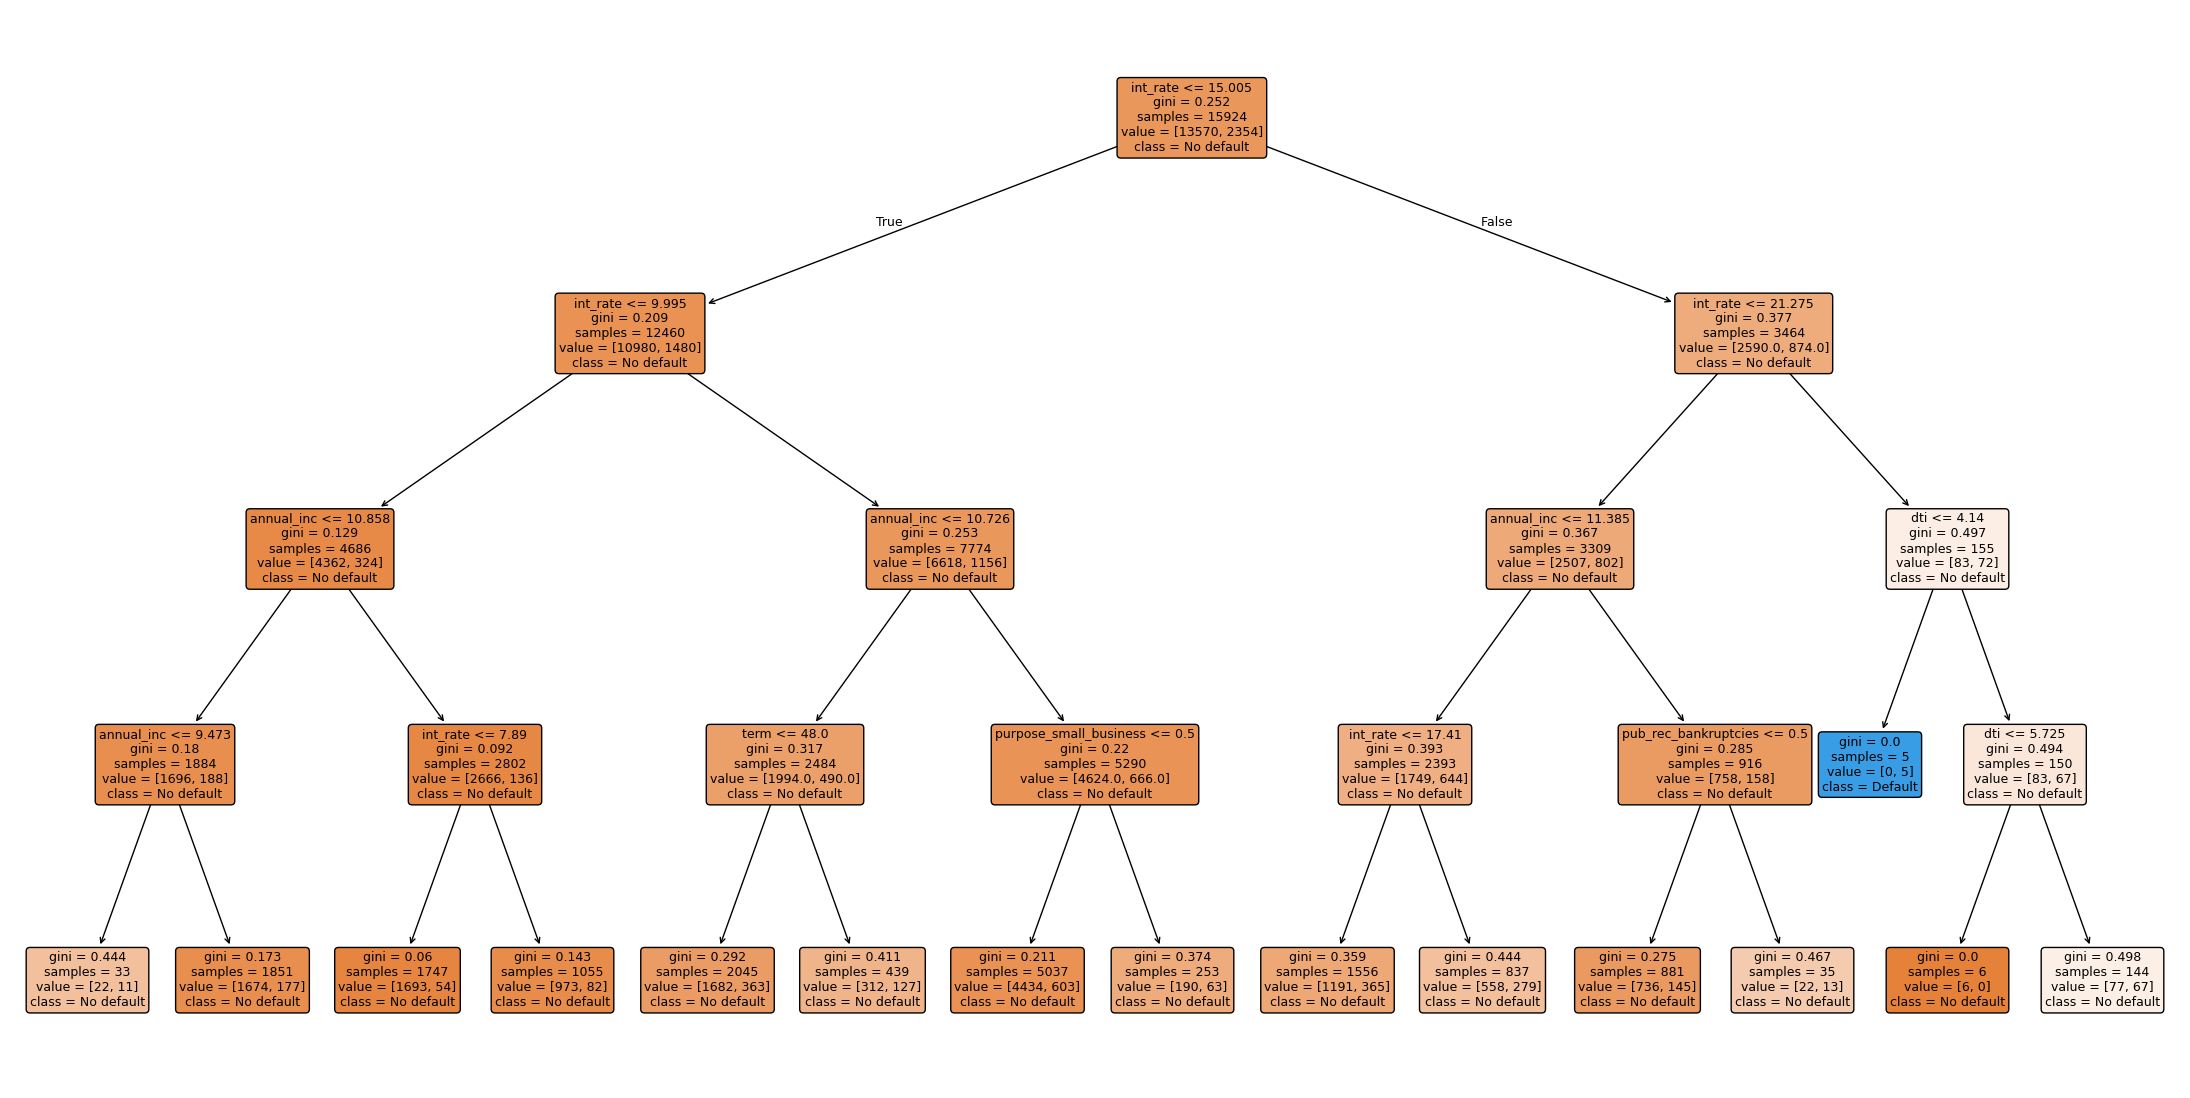

In [43]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(28, 14))  # ← aumenta bastante el lienzo
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=['No default', 'Default'],
    filled=True,
    rounded=True,
    fontsize=9        # ← reduce tamaño del texto
)
plt.show()



#Random Forest Classifier + GridSearch
Atacamos directamente el problema que viste en LR y en el Árbol:
la mala detección de la clase 1 (default).

#Definir el modelo base (con ponderación de clases)

class_weight='balanced' hace que el modelo penalice más los errores en la clase minoritaria.

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)


###Definición de los hiperparámetros

In [46]:
param_grid = {
    'n_estimators': [150, 200, 250],
    'max_leaf_nodes': [12, 14, 16],
    'max_features': [5, 6, 7],
    'min_samples_leaf': [1, 2, 3]
}


###GridSearch con validación cruzada

Se utilizó GridSearchCV con validación cruzada de 5 particiones (cv=5) para entrenar un modelo RandomForestClassifier, optimizando la métrica ROC AUC, que es especialmente adecuada en problemas de clasificación con clases desbalanceadas.

El modelo base se entrenó usando class_weight='balanced', lo cual ajusta automáticamente los pesos de las clases en función de su frecuencia y ayuda a mejorar la detección de la clase minoritaria (loan_status = 1).

Tras evaluar todas las combinaciones del espacio de hiperparámetros definido, el mejor estimador encontrado fue:

n_estimators = 250: se utilizaron 250 árboles, lo que aumenta la estabilidad del ensamble.

max_leaf_nodes = 16: se limita la complejidad de cada árbol para reducir sobreajuste.

max_features = 6: en cada división del árbol se consideran 6 variables aleatorias.

min_samples_leaf = 3: cada hoja debe tener al menos 3 observaciones, lo que suaviza las predicciones.

Este conjunto de hiperparámetros logra el mejor compromiso entre capacidad predictiva y control del sobreajuste, maximizando el desempeño medido por ROC AUC en validación cruzada. El Random Forest optimizado mejora la capacidad de discriminación del modelo respecto a los modelos individuales, manteniendo un control explícito de la complejidad y del desbalance de clases.

En pocas palabras, el GridSearchCV evaluó distintas combinaciones de hiperparámetros del modelo Random Forest y seleccionó automáticamente aquella que maximiza el desempeño (ROC AUC). Como resultado, el modelo óptimo se entrena utilizando únicamente el conjunto de hiperparámetros que mostró el mejor rendimiento:
{'max_features': 6, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'n_estimators': 250}.

In [47]:
from sklearn.model_selection import GridSearchCV

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='roc_auc',   # métrica adecuada para desbalance
    cv=5,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_features': [5, 6, 7],
                         'max_leaf_nodes': [12, 14, 16],
                         'min_samples_leaf': [1, 2, 3],
                         'n_estimators': [150, 200, 250]},
             scoring='roc_auc')

###Mejor modelo encontrado

In [48]:
best_rf = grid_rf.best_estimator_

print("Mejores hiperparámetros:")
print(grid_rf.best_params_)


Mejores hiperparámetros:
{'max_features': 6, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'n_estimators': 250}


###Predicción y evaluación

In [49]:
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.6302436573725194
ROC AUC: 0.6832910553544543
              precision    recall  f1-score   support

           0       0.91      0.63      0.74      3392
           1       0.23      0.63      0.33       589

    accuracy                           0.63      3981
   macro avg       0.57      0.63      0.54      3981
weighted avg       0.81      0.63      0.68      3981



#Modelo SVM (Support Vector Machine)
Se entrena un modelo SVM para clasificación binaria y se evalúa su desempeño usando Accuracy, ROC AUC y matriz de clasificación, igual que en los modelos anteriores, para poder compararlos.

En este paso se entrenó un modelo SVM con kernel RBF. Dado el desbalance de la variable objetivo, se incorporó el parámetro class_weight='balanced'. El desempeño del modelo se evaluó mediante Accuracy, ROC AUC y el reporte de clasificación, permitiendo compararlo con los modelos previamente estimados

In [51]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Definir el modelo SVM
svm_model = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)

# Entrenamiento
svm_model.fit(X_train, y_train)

# Predicciones
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# Métricas
accuracy_svm = accuracy_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_prob_svm)

print("Accuracy:", accuracy_svm)
print("ROC AUC:", roc_auc_svm)
print(classification_report(y_test, y_pred_svm))


Accuracy: 0.6656618939964833
ROC AUC: 0.6542433810103471
              precision    recall  f1-score   support

           0       0.89      0.69      0.78      3392
           1       0.22      0.50      0.31       589

    accuracy                           0.67      3981
   macro avg       0.56      0.60      0.54      3981
weighted avg       0.79      0.67      0.71      3981



##Voting Classifier (LR + RF)
Se estimó un Voting Classifier combinando Regresión Logística y Random Forest mediante votación suave. Este enfoque permite promediar las probabilidades predichas por ambos modelos, buscando mejorar la capacidad predictiva respecto a los modelos individuales.

El Voting Classifier muestra una reducción en la exactitud global respecto a los modelos individuales, pero logra un aumento sustancial en el recall de la clase minoritaria. Esto indica que el modelo prioriza la detección de eventos positivos, lo cual es consistente con el uso de ponderación por clases y métricas basadas en probabilidad como el ROC AUC. El descenso en accuracy refleja el trade-off entre sensibilidad y precisión en contextos de desbalance de clases.

In [53]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Modelos base
lr = LogisticRegression(
    max_iter=3000,
    class_weight='balanced',
    random_state=42
)

rf = RandomForestClassifier(
    class_weight='balanced',
    max_features=6,
    max_leaf_nodes=16,
    min_samples_leaf=3,
    n_estimators=250,
    random_state=42
)

# Voting Classifier
voting_model = VotingClassifier(
    estimators=[('lr', lr), ('rf', rf)],
    voting='soft'
)

# Entrenamiento
voting_model.fit(X_train, y_train)

# Predicciones
y_pred_vote = voting_model.predict(X_test)
y_prob_vote = voting_model.predict_proba(X_test)[:, 1]

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred_vote))
print("ROC AUC:", roc_auc_score(y_test, y_prob_vote))
print(classification_report(y_test, y_pred_vote))


Accuracy: 0.6450640542577242
ROC AUC: 0.6920488035365346
              precision    recall  f1-score   support

           0       0.91      0.65      0.76      3392
           1       0.23      0.61      0.34       589

    accuracy                           0.65      3981
   macro avg       0.57      0.63      0.55      3981
weighted avg       0.81      0.65      0.70      3981



#Stacking Classifier (LR, RF, SVC → LR)
Se implementó un Stacking Classifier combinando Regresión Logística, Random Forest y SVM como modelos base, utilizando una Regresión Logística como meta-clasificador. Este enfoque permite capturar patrones complementarios entre modelos y potencialmente mejorar el desempeño predictivo.

In [54]:
from sklearn.ensemble import StackingClassifier

# Modelos base
estimators = [
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ('rf', RandomForestClassifier(
        class_weight='balanced',
        max_features=6,
        max_leaf_nodes=16,
        min_samples_leaf=3,
        n_estimators=250,
        random_state=42
    )),
    ('svm', SVC(
        kernel='rbf',
        C=1,
        gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42
    ))
]

# Meta-modelo
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

# Entrenamiento
stacking_model.fit(X_train, y_train)

# Predicciones
y_pred_stack = stacking_model.predict(X_test)
y_prob_stack = stacking_model.predict_proba(X_test)[:, 1]

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print("ROC AUC:", roc_auc_score(y_test, y_prob_stack))
print(classification_report(y_test, y_pred_stack))


Accuracy: 0.8520472243154986
ROC AUC: 0.6927870831598167
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      3392
           1       0.00      0.00      0.00       589

    accuracy                           0.85      3981
   macro avg       0.43      0.50      0.46      3981
weighted avg       0.73      0.85      0.78      3981



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Matriz de confusión por modelo

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion(y_true, y_pred, model_name, dataset):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["Real 0", "Real 1"]
    )
    plt.xlabel("Estimación")
    plt.ylabel("Valor Real")
    plt.title(f"Matriz de Confusión - {model_name} ({dataset})")
    plt.show()


##Logistic Regression

In [59]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=3000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=3000, random_state=42)

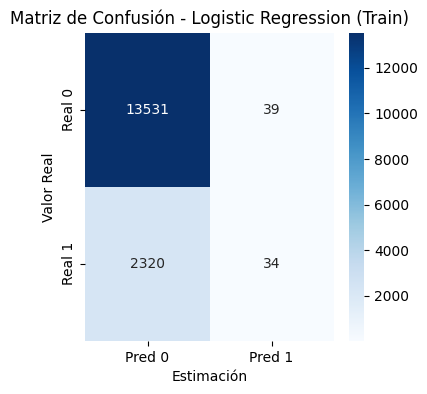

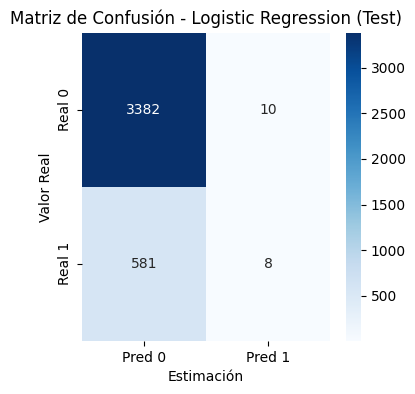

In [60]:
y_train_pred_lr = lr.predict(X_train_scaled)
plot_confusion(y_train, y_train_pred_lr, "Logistic Regression", "Train")

y_test_pred_lr = lr.predict(X_test_scaled)
plot_confusion(y_test, y_test_pred_lr, "Logistic Regression", "Test")


##arbol de decision

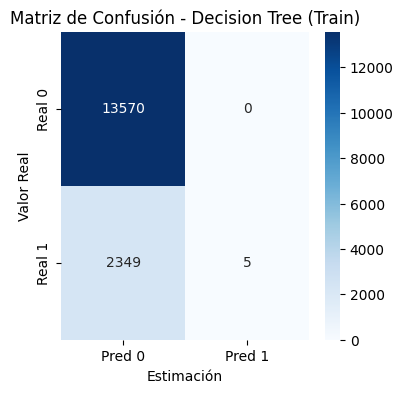

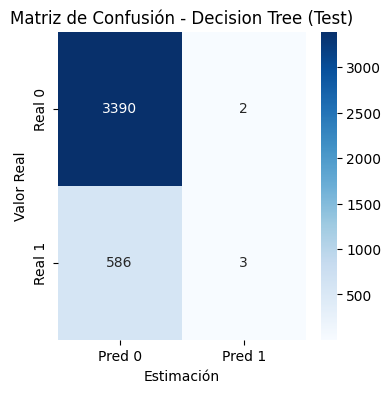

In [61]:
# Train
y_train_pred_dt = dt.predict(X_train)
plot_confusion(y_train, y_train_pred_dt, "Decision Tree", "Train")

# Test
y_test_pred_dt = dt.predict(X_test)
plot_confusion(y_test, y_test_pred_dt, "Decision Tree", "Test")


##Random forest

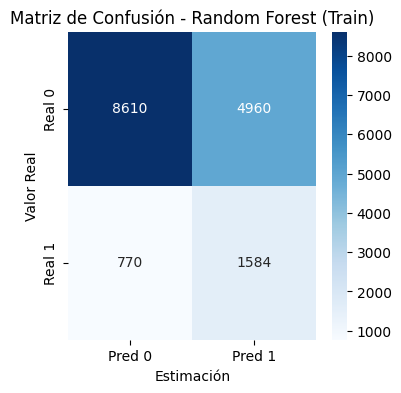

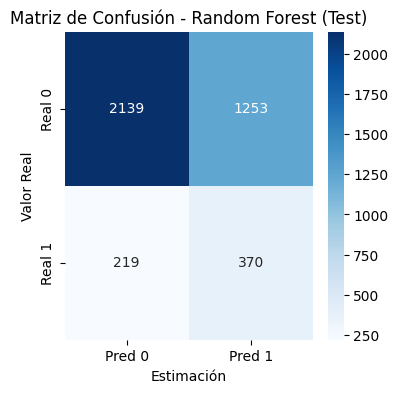

In [62]:
# Train
y_train_pred_rf = best_rf.predict(X_train)
plot_confusion(y_train, y_train_pred_rf, "Random Forest", "Train")

# Test
y_test_pred_rf = best_rf.predict(X_test)
plot_confusion(y_test, y_test_pred_rf, "Random Forest", "Test")


##SVM (Support Vector Machine)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


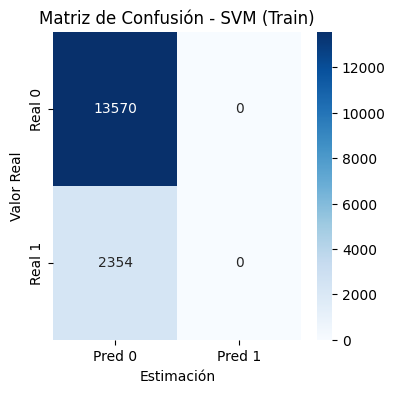

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


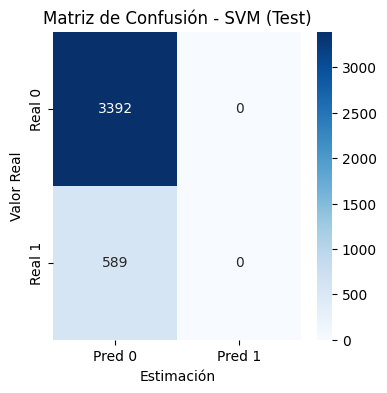

In [64]:
# Train
y_train_pred_svm = svm_model.predict(X_train_scaled)
plot_confusion(y_train, y_train_pred_svm, "SVM", "Train")

# Test
y_test_pred_svm = svm_model.predict(X_test_scaled)
plot_confusion(y_test, y_test_pred_svm, "SVM", "Test")


##Stacking Classifier

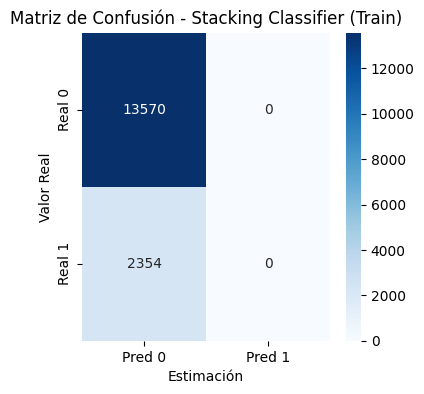

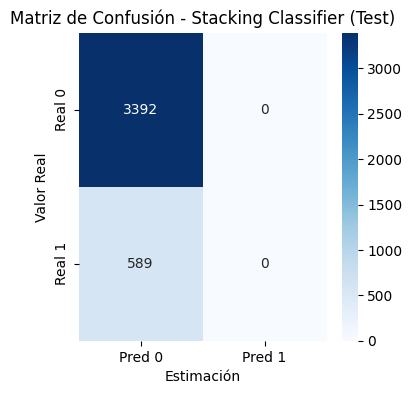

In [66]:
# Train
y_train_pred_stack = stacking_model.predict(X_train)
plot_confusion(y_train, y_train_pred_stack, "Stacking Classifier", "Train")

# Test
y_test_pred_stack = stacking_model.predict(X_test)
plot_confusion(y_test, y_test_pred_stack, "Stacking Classifier", "Test")


##Voting Classifier

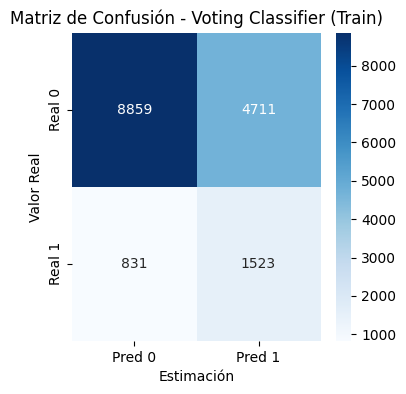

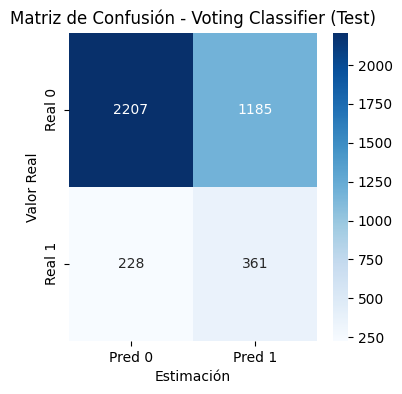

In [68]:
# Train
y_train_pred_vote = voting_model.predict(X_train)
plot_confusion(y_train, y_train_pred_vote, "Voting Classifier", "Train")

# Test
y_test_pred_vote = voting_model.predict(X_test)
plot_confusion(y_test, y_test_pred_vote, "Voting Classifier", "Test")


#Curvas ROC

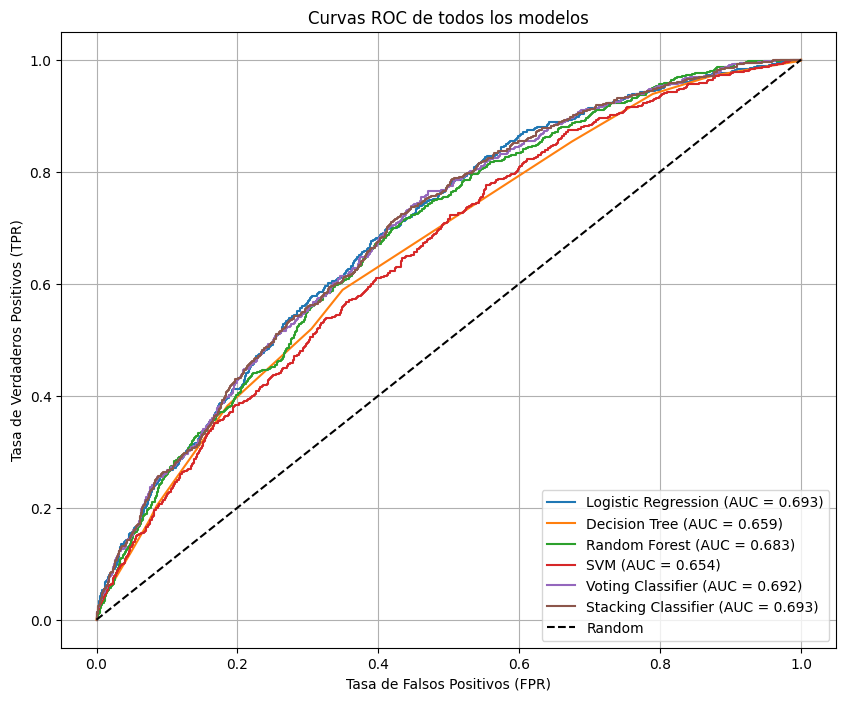

In [69]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Lista de modelos y nombres
models = [
    ('Logistic Regression', pipe_lr),
    ('Decision Tree', dt),
    ('Random Forest', best_rf),
    ('SVM', svm_model),
    ('Voting Classifier', voting_model),
    ('Stacking Classifier', stacking_model)
]

plt.figure(figsize=(10, 8))

# Generar curvas ROC
for name, model in models:
    # Predecir probabilidades
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:  # Algunos modelos como SVC requieren probability=True
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

# Diagonal de referencia
plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.title('Curvas ROC de todos los modelos')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [70]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Lista de modelos y nombres
models = [
    ('Logistic Regression', pipe_lr),
    ('Decision Tree', dt),
    ('Random Forest', best_rf),
    ('SVM', svm_model),
    ('Voting Classifier', voting_model),
    ('Stacking Classifier', stacking_model)
]

# Crear lista para guardar resultados
results = []

for name, model in models:
    for dataset_name, X, y in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
        y_pred = model.predict(X)

        # Accuracy total y por clase
        acc_total = accuracy_score(y, y_pred)
        acc_class0 = (y_pred[y==0] == 0).mean()
        acc_class1 = (y_pred[y==1] == 1).mean()

        # Precision, Recall, F1 por clase
        precision = precision_score(y, y_pred, average=None, zero_division=0)
        recall = recall_score(y, y_pred, average=None, zero_division=0)
        f1 = f1_score(y, y_pred, average=None, zero_division=0)

        results.append({
            'Modelo': name,
            'Dataset': dataset_name,
            'Acc Total': round(acc_total, 2),
            'Acc Clase 0': round(acc_class0, 2),
            'Acc Clase 1': round(acc_class1, 2),
            'Precision Clase 0': round(precision[0], 2),
            'Precision Clase 1': round(precision[1], 2),
            'Recall Clase 0': round(recall[0], 2),
            'Recall Clase 1': round(recall[1], 2),
            'F1 Clase 0': round(f1[0], 2),
            'F1 Clase 1': round(f1[1], 2)
        })

# Convertir a DataFrame
df_results = pd.DataFrame(results)

# Mostrar tabla
pd.set_option('display.max_rows', None)
print(df_results)


                 Modelo Dataset  Acc Total  Acc Clase 0  Acc Clase 1  \
0   Logistic Regression   Train     0.8500       1.0000       0.0100   
1   Logistic Regression    Test     0.8500       1.0000       0.0100   
2         Decision Tree   Train     0.8500       1.0000       0.0000   
3         Decision Tree    Test     0.8500       1.0000       0.0100   
4         Random Forest   Train     0.6400       0.6300       0.6700   
5         Random Forest    Test     0.6300       0.6300       0.6300   
6                   SVM   Train     0.6800       0.7100       0.5000   
7                   SVM    Test     0.6700       0.6900       0.5000   
8     Voting Classifier   Train     0.6500       0.6500       0.6500   
9     Voting Classifier    Test     0.6500       0.6500       0.6100   
10  Stacking Classifier   Train     0.8500       1.0000       0.0000   
11  Stacking Classifier    Test     0.8500       1.0000       0.0000   

    Precision Clase 0  Precision Clase 1  Recall Clase 0  Recal

#3)Comentarios modelos
**Overfitting / Underfitting / Generalización**

Logistic Regression y Stacking Classifier:

-Accuracy Train ≈ Test (0.85) → buena generalización global.

-clase 1 casi no predicha → sesgo por desbalance, no overfitting.

-ROC AUC ≈ 0.693 → indica discriminación limitada para la clase minoritaria.

Decision Tree:

-Accuracy similar en Train y Test → buena generalización.

-Clase 1 muy baja → falla en clase minoritaria.

-ROC AUC = 0.659 → discriminación peor que LR y Stacking.

Random Forest:

-Train 0.64, Test 0.63 → generalización buena.

-Clase 0 y 1 equilibradas → aprende ambas clases.

-ROC AUC = 0.683 → mejor equilibrio y discriminación que Decision Tree.

SVM:

-Train 0.68, Test 0.67 → generalización adecuada.

-Clase 1 ≈ 0.50 → mejor que LR/Stacking pero inferior a RF.

-ROC AUC = 0.654 → discriminación moderada.

Voting Classifier:

-Train 0.65, Test 0.65 → generalización buena.

-Clase 1 ≈ 0.61 → equilibrio razonable.

-ROC AUC = 0.692 → casi igual que Logistic Regression.

**Interpretación del ROC/AUC**

Los modelos con AUC más alto muestran mejor capacidad de distinguir entre clases 0 y 1:

-Stacking y Logistic Regression (0.693) → pero clase 1 casi ignorada → alto Accuracy engañoso.

-Voting Classifier (0.692) → similar, ligeramente mejor clase minoritaria.

-Random Forest (0.683) → buen balance entre clases y discriminación.

-Decision Tree y SVM → AUC más bajo → discriminación menor.

**Mejor modelo**

-Considerando: Accuracy total, Accuracy por clase, F1, ROC/AUC

-Random Forest es el más equilibrado:

Accuracy total razonable (0.63 Test)

Accuracy clase 0 y 1 similares

F1 clase 1 > LR/Stacking

-ROC/AUC decente → discriminación aceptable

Los demás modelos tienen Accuracy alto pero ignoran clase minoritaria → AUC engañoso.

#4) Evaluación de Variables : Comparación de peso/importancia

##a)
La importancia de las variables se analizó usando dos métodos distintos. Primero, se utilizó la regresión logística, donde los coeficientes muestran cómo cada variable influye en la probabilidad de que ocurra el evento analizado. El signo del coeficiente indica si la variable aumenta o reduce dicha probabilidad. Segundo, se utilizó el modelo de random forest, del cual se obtuvo la importancia de cada variable según qué tan útil es para separar correctamente los datos.

La comparación entre ambos métodos permite identificar qué variables tienen mayor influencia en el modelo y cuáles aportan poca información. Esta evaluación no busca comparar el rendimiento de los modelos, sino entender el peso relativo de cada variable en la explicación del fenómeno estudiado.

-Coef_LR
Coeficiente estimado por la regresión logística.
Indica cómo cambia la probabilidad del evento cuando la variable aumenta:

positivo → la probabilidad aumenta

negativo → la probabilidad disminuye

-Abs_Coef_LR
Valor absoluto del coeficiente de la regresión logística.
Mide qué tan fuerte es la influencia de la variable, sin importar el signo.

-Imp_RF
Importancia de la variable en el random forest.
Muestra qué tan útil es la variable para separar los datos dentro del modelo.
Valores más altos ⇒ mayor importancia.

-Coef_LR_norm
Coeficiente de la regresión logística normalizado.
Permite comparar la importancia relativa de las variables dentro del modelo logístico.

-Imp_RF_norm
Importancia del random forest normalizada.
Permite comparar el peso relativo de cada variable dentro del conjunto total de variables.

In [72]:

# Nombres de variables
feature_names = X_train.columns

# --- Regresión Logística ---
# Si usaste pipeline
coef_lr = pipe_lr.named_steps['lr'].coef_[0]

# --- Random Forest ---
imp_rf = best_rf.feature_importances_

# Tabla comparativa
tabla_importancia = pd.DataFrame({
    'Variable': feature_names,
    'Coef_LR': coef_lr,
    'Abs_Coef_LR': np.abs(coef_lr),
    'Imp_RF': imp_rf
})

# Normalizamos para comparar mejor (opcional pero recomendado)
tabla_importancia['Coef_LR_norm'] = tabla_importancia['Abs_Coef_LR'] / tabla_importancia['Abs_Coef_LR'].sum()
tabla_importancia['Imp_RF_norm'] = tabla_importancia['Imp_RF'] / tabla_importancia['Imp_RF'].sum()

# Ordenar por RF (o por LR, según te pidan)
tabla_importancia = tabla_importancia.sort_values(
    by='Imp_RF_norm', ascending=False
).reset_index(drop=True)

tabla_importancia


,Variable,Coef_LR,Abs_Coef_LR,Imp_RF,Coef_LR_norm,Imp_RF_norm
0,int_rate,0.4469,0.4469,0.3839,0.1745,0.3839
1,term,0.1960,0.1960,0.2134,0.0765,0.2134
2,annual_inc,-0.3300,0.3300,0.1252,0.1289,0.1252
3,revol_util,0.1145,0.1145,0.0849,0.0447,0.0849
4,loan_amnt,0.0321,0.0321,0.0447,0.0125,0.0447
5,purpose_small_business,0.1882,0.1882,0.0392,0.0735,0.0392
6,dti,0.0475,0.0475,0.0370,0.0186,0.0370
7,emp_length,0.1039,0.1039,0.0147,0.0406,0.0147
8,emp_title_missing,0.0334,0.0334,0.0078,0.0130,0.0078
9,verification_Verified,0.0152,0.0152,0.0072,0.0059,0.0072


##b)  
**Gráfico 1: Regresión Logística**

-El gráfico muestra el peso relativo de cada variable según la regresión logística.

-Las barras más altas (por ejemplo, int_rate, annual_inc, state_OTHER) indican variables con mayor influencia lineal.

-El signo del efecto no se ve en el gráfico, solo la magnitud de la influencia.

-La importancia está más repartida entre varias variables.

Lectura clave: muchas variables tienen efectos pequeños pero constantes.

**Gráfico 2: Random Forest**

-El gráfico muestra la importancia de cada variable en el random forest.

-Se observa que pocas variables concentran casi toda la influencia, especialmente int_rate y term.

-La mayoría de variables tiene un peso cercano a cero.

-Lectura clave: el modelo se apoya fuertemente en pocas variables para separar los datos.

**Comparación entre modelos**

La regresión logística distribuye la influencia entre un mayor número de variables, mientras que el random forest concentra la importancia en pocas variables clave. Esto indica que las variables financieras principales explican la mayor parte del resultado, y que muchas variables categóricas aportan información limitada cuando se consideran relaciones más complejas.

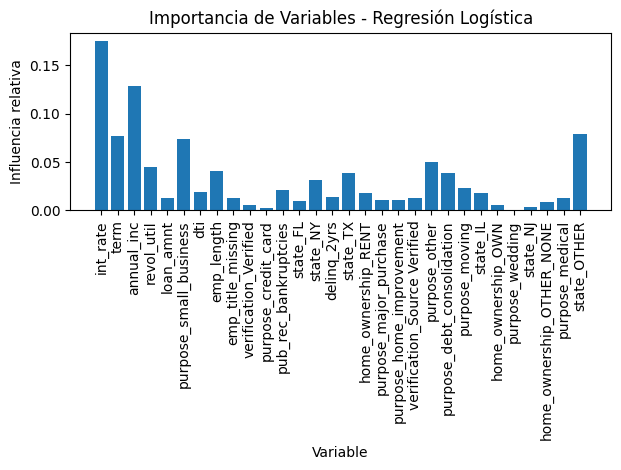

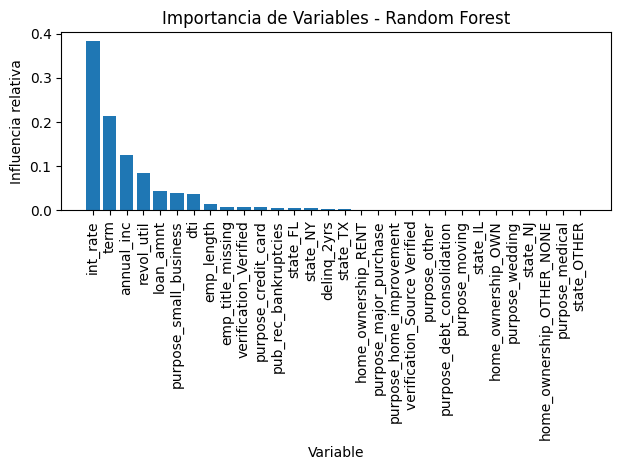

In [73]:
# --- Gráfico 1: Regresión Logística ---
plt.figure()
plt.bar(
    tabla_importancia["Variable"],
    tabla_importancia["Coef_LR_norm"]
)
plt.xticks(rotation=90)
plt.xlabel("Variable")
plt.ylabel("Influencia relativa")
plt.title("Importancia de Variables - Regresión Logística")
plt.tight_layout()
plt.show()

# --- Gráfico 2: Random Forest ---
plt.figure()
plt.bar(
    tabla_importancia["Variable"],
    tabla_importancia["Imp_RF_norm"]
)
plt.xticks(rotation=90)
plt.xlabel("Variable")
plt.ylabel("Influencia relativa")
plt.title("Importancia de Variables - Random Forest")
plt.tight_layout()
plt.show()


#5) Comentarios de las variables:

##Regresión Logistica
El modelo estima la probabilidad de que un préstamo termine en Charged Off, entendido como un estado de impago, frente a Fully Paid, que corresponde a préstamos pagados completamente

In [77]:
print("INTERPRETACIÓN AUTOMÁTICA – REGRESIÓN LOGÍSTICA\n")
print("Definición de la variable objetivo:")
print("Charged Off: préstamo en estado de incumplimiento (impago).")
print("Fully Paid: préstamo pagado en su totalidad.\n")

for _, row in tabla_importancia.iterrows():
    variable = row["Variable"]
    coef = row["Coef_LR"]

    if coef > 0:
        signo = "positivo (+)"
        interpretacion = (
            "Un aumento en esta variable está asociado con un incremento "
            "en la probabilidad de que el préstamo sea Charged Off (impago)."
        )
    elif coef < 0:
        signo = "negativo (-)"
        interpretacion = (
            "Un aumento en esta variable está asociado con una disminución "
            "en la probabilidad de que el préstamo sea Charged Off, "
            "es decir, una mayor probabilidad de que sea Fully Paid."
        )
    else:
        signo = "nulo (0)"
        interpretacion = (
            "La variable no muestra una asociación clara con el estado del préstamo."
        )

    print(f"Variable: {variable}")
    print(f"  Coef_LR: {coef:.4f} → Signo {signo}")
    print(f"  Interpretación: {interpretacion}\n")


INTERPRETACIÓN AUTOMÁTICA – REGRESIÓN LOGÍSTICA

Definición de la variable objetivo:
Charged Off: préstamo en estado de incumplimiento (impago).
Fully Paid: préstamo pagado en su totalidad.

Variable: int_rate
  Coef_LR: 0.4469 → Signo positivo (+)
  Interpretación: Un aumento en esta variable está asociado con un incremento en la probabilidad de que el préstamo sea Charged Off (impago).

Variable: term
  Coef_LR: 0.1960 → Signo positivo (+)
  Interpretación: Un aumento en esta variable está asociado con un incremento en la probabilidad de que el préstamo sea Charged Off (impago).

Variable: annual_inc
  Coef_LR: -0.3300 → Signo negativo (-)
  Interpretación: Un aumento en esta variable está asociado con una disminución en la probabilidad de que el préstamo sea Charged Off, es decir, una mayor probabilidad de que sea Fully Paid.

Variable: revol_util
  Coef_LR: 0.1145 → Signo positivo (+)
  Interpretación: Un aumento en esta variable está asociado con un incremento en la probabilidad d

##Random Forest
En el modelo Random Forest, la importancia de las variables se mide a través del indicador feature_importance, el cual refleja qué tan relevante es cada variable en las decisiones del modelo. La variable con mayor valor de importancia es aquella que más contribuye a la clasificación de los préstamos. En este enfoque no se considera el signo del efecto, sino únicamente la magnitud relativa de la influencia de cada variable.

In [78]:
print("INTERPRETACIÓN AUTOMÁTICA – RANDOM FOREST\n")

# Identificar la variable con mayor importancia
idx_max = tabla_importancia["Imp_RF"].idxmax()
var_mas_importante = tabla_importancia.loc[idx_max, "Variable"]
valor_max = tabla_importancia.loc[idx_max, "Imp_RF"]

print(f"La variable con mayor importancia en el Random Forest es: {var_mas_importante}")
print(f"Importancia (Imp_RF): {valor_max:.4f}")
print("Interpretación: Es la variable que más contribuye a las decisiones del modelo.\n")

# Comentario general para todas las variables
print("Importancia relativa de las variables (Random Forest):\n")

for _, row in tabla_importancia.iterrows():
    variable = row["Variable"]
    importancia = row["Imp_RF"]

    print(f"Variable: {variable}")
    print(f"  Imp_RF: {importancia:.4f}")
    print(
        "  Interpretación: La magnitud indica qué tan relevante es esta variable "
        "en las decisiones del modelo. Valores más altos implican mayor influencia.\n"
    )


INTERPRETACIÓN AUTOMÁTICA – RANDOM FOREST

La variable con mayor importancia en el Random Forest es: int_rate
Importancia (Imp_RF): 0.3839
Interpretación: Es la variable que más contribuye a las decisiones del modelo.

Importancia relativa de las variables (Random Forest):

Variable: int_rate
  Imp_RF: 0.3839
  Interpretación: La magnitud indica qué tan relevante es esta variable en las decisiones del modelo. Valores más altos implican mayor influencia.

Variable: term
  Imp_RF: 0.2134
  Interpretación: La magnitud indica qué tan relevante es esta variable en las decisiones del modelo. Valores más altos implican mayor influencia.

Variable: annual_inc
  Imp_RF: 0.1252
  Interpretación: La magnitud indica qué tan relevante es esta variable en las decisiones del modelo. Valores más altos implican mayor influencia.

Variable: revol_util
  Imp_RF: 0.0849
  Interpretación: La magnitud indica qué tan relevante es esta variable en las decisiones del modelo. Valores más altos implican mayor in